# Final Project: UCI Adult Income Classification
## Author: Sadegh Khajeour
## Date: 2025-12-23
## Dataset: UCI Adult Income Dataset (via ucimlrepo)

In [1]:
# !pip install ucimlrepo --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


### Objective
The purpose of this analysis is to predict whether an individual earns **more than $50K per year** based on demographic and employment features. 

This classification model will help stakeholders identify patterns in income distribution and enable decision-making for policy, marketing, or HR analytics purposes. We aim to:
1. Explore and preprocess the dataset.
2. Train multiple classification models.
3. Compare models for accuracy and interpretability.
4. Provide actionable insights based on the best model.


In [3]:
from ucimlrepo import fetch_ucirepo

# Fetch the dataset
dataset = fetch_ucirepo('Adult')  # Returns a dictionary

In [4]:
dataset.keys()

dict_keys(['data', 'metadata', 'variables'])

In [5]:
dataset.get('variables')

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,N/A,None,no
1,workclass,Feature,Categorical,Income,"Private, Self-emp-not-inc, Self-emp-inc, Feder...",None,yes
2,fnlwgt,Feature,Integer,None,None,None,no
3,education,Feature,Categorical,Education Level,"Bachelors, Some-college, 11th, HS-grad, Prof-...",None,no
4,education-num,Feature,Integer,Education Level,None,None,no
5,marital-status,Feature,Categorical,Other,"Married-civ-spouse, Divorced, Never-married, S...",None,no
6,occupation,Feature,Categorical,Other,"Tech-support, Craft-repair, Other-service, Sal...",None,yes
7,relationship,Feature,Categorical,Other,"Wife, Own-child, Husband, Not-in-family, Other...",None,no
8,race,Feature,Categorical,Race,"White, Asian-Pac-Islander, Amer-Indian-Eskimo,...",None,no
9,sex,Feature,Binary,Sex,"Female, Male.",None,no


In [6]:
dataset.get('data').keys()

dict_keys(['ids', 'features', 'targets', 'original', 'headers'])

In [7]:
# Fetch UCI Adult dataset using ucimlrepo
df = dataset.get('data').get('original')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
# Dataset overview
df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,47879,4.884200e+04,48842,48842.000000,48842,47876,48842,48842,48842,48842.000000,48842.000000,48842.000000,48568,48842
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,4
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,24720
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


### Exploration
- Check for missing values.
- Examine distribution of the target variable.
- Visualize numeric features.


In [9]:
# Check missing values
df.isna().sum()


age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

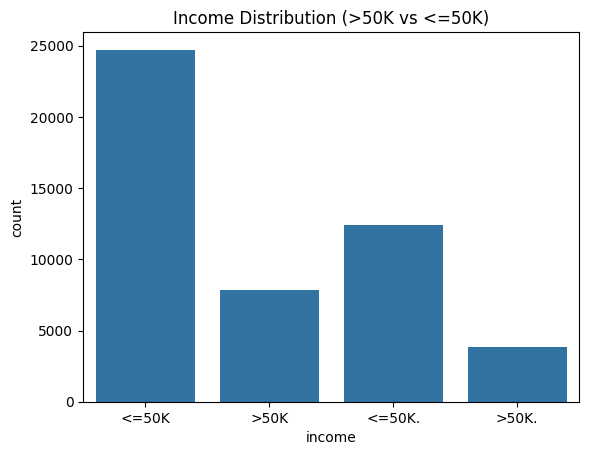

In [10]:
# Target variable distribution
sns.countplot(x='income', data=df)
plt.title('Income Distribution (>50K vs <=50K)')
plt.show()


### Data Cleaning & Feature Engineering
- Remove missing values.
- Encode categorical variables with one-hot encoding.
- Convert target variable to binary (0: <=50K, 1: >50K).


In [20]:
# Remove missing values
df.dropna(inplace=True)

# Encode categorical variables
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('income')

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Encode target variable
df_encoded['income'] = df['income'].map({
    '<=50K': 0,
    '<=50K.': 0,
    '>50K': 1,
    '>50K.': 1
})

df_encoded.head()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [22]:
X = df_encoded.drop('income', axis=1)
y = df_encoded['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape}, Test set: {X_test.shape}')


Training set: (36177, 96), Test set: (9045, 96)


In [23]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }


/home/sadegh/base/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
# Display results
for name, res in results.items():
    print(f"### {name}")
    print(f"Accuracy: {res['accuracy']:.4f}")
    print(res['classification_report'])
    
    # plt.figure(figsize=(5,4))
    # sns.heatmap(res['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
    # plt.title(f'{name} - Confusion Matrix')
    # plt.xlabel('Predicted')
    # plt.ylabel('Actual')
    # plt.show()


### Logistic Regression
Accuracy: 0.8432
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6745
           1       0.74      0.59      0.66      2300

    accuracy                           0.84      9045
   macro avg       0.81      0.76      0.78      9045
weighted avg       0.84      0.84      0.84      9045

### Random Forest
Accuracy: 0.8544
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6745
           1       0.75      0.63      0.69      2300

    accuracy                           0.85      9045
   macro avg       0.82      0.78      0.80      9045
weighted avg       0.85      0.85      0.85      9045

### Gradient Boosting
Accuracy: 0.8636
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      6745
           1       0.81      0.60      0.69      2300

    accuracy                           0.86      9045
   macro avg 

## Overall Performance Comparison

| Model | Accuracy | Precision (>50K) | Recall (>50K) | F1-Score (>50K) | Key Strengths |
|-------|----------|------------------|---------------|-----------------|---------------|
| **Logistic Regression** | 84.32% | 74% | 59% | 66% | Good interpretability |
| **Random Forest** | 85.44% | 75% | 63% | 69% | Balanced performance |
| **Gradient Boosting** | **86.36%** | **81%** | 60% | 69% | **Best overall accuracy** |


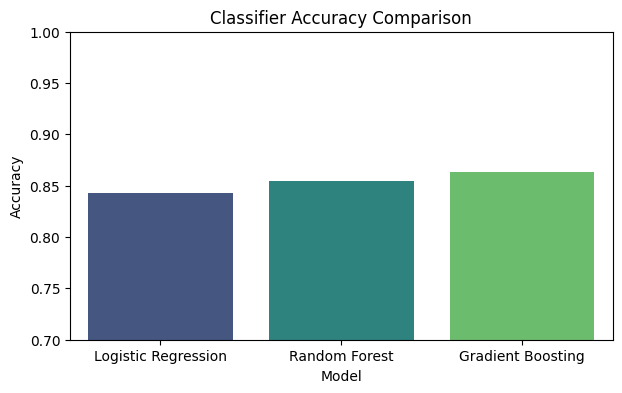

In [27]:
# Accuracy comparison
model_names = list(results.keys())
accuracy_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

plt.figure(figsize=(7,4))
sns.barplot(data=accuracy_df, x='Model', y='Accuracy', hue='Model', dodge=False, palette='viridis')
plt.title('Classifier Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1)
plt.legend([],[], frameon=False)  # optional: remove legend if unnecessary
plt.show()


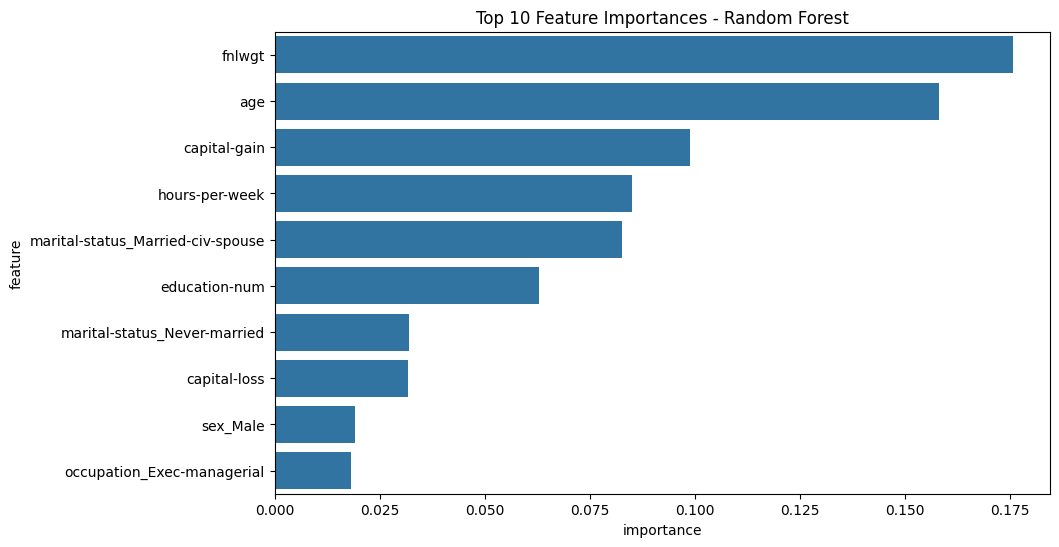

In [16]:
importances = models['Random Forest'].feature_importances_
feat_imp_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
feat_imp_df.sort_values(by='importance', ascending=False, inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feat_imp_df.head(10))
plt.title('Top 10 Feature Importances - Random Forest')
plt.show()


### Key Insights
- Higher education, capital gains, and hours per week are strong predictors of high income.
- Marital status and occupation type are important categorical features.
- Income >50K is concentrated among individuals with specific demographic and employment profiles.

These insights can help stakeholders target income-related interventions or policies.


### Limitations
- Imbalanced classes may bias model predictions.
- Some categorical variables have many levels, reducing interpretability.
- Correlated features may affect feature importance.

### Next Steps
1. Apply oversampling (SMOTE) for class balancing.
2. Experiment with XGBoost or LightGBM for potentially better accuracy.
3. Conduct deeper feature selection to improve interpretability.
4. Deploy the model for live prediction and continuous monitoring.
